# SympleQ: Clifford circuit simulation with a thousand ubits

In this notebook we show a different kind of classical simulation.

Instead of storing the quantum statevector, we track how Pauli operators transform under a Clifford circuit.

For a Clifford unitary \(U\), a Pauli operator \(P\) transforms as

$$
P \mapsto U^\dagger P U .
$$

The result is still a Pauli operator.

This is the algebraic reason Clifford circuits can be simulated efficiently.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import sympleq

from sympleq.core.circuits import Circuit, GATES
from sympleq.core.paulis import PauliSum, PauliString

In [2]:
H = GATES.H
S = GATES.S
CX = GATES.CX
CZ = GATES.CZ

## 1. A small PauliSum example

A PauliString is one product of Pauli operators.

A PauliSum is a weighted sum of PauliStrings.

For example,

$$
A = 1.0 Z_0 + 0.5 X_1 - 1.2 Z_0 Z_1 .
$$

We will construct this directly using `PauliString.from_exponents(...)` and `PauliSum.from_pauli_strings(...)`.

In [3]:
dimensions = [2, 2, 2]

z0 = PauliString.from_exponents(
    x_exp=[0, 0, 0],
    z_exp=[1, 0, 0],
    dimensions=dimensions,
)

x1 = PauliString.from_exponents(
    x_exp=[0, 1, 0],
    z_exp=[0, 0, 0],
    dimensions=dimensions,
)

z0z1 = PauliString.from_exponents(
    x_exp=[0, 0, 0],
    z_exp=[1, 1, 0],
    dimensions=dimensions,
)

A = PauliSum.from_pauli_strings(
    [z0, x1, z0z1],
    weights=[1.0, 0.5, -1.2],
)

print(A)

(1+0j)   |x0z1 x0z0 x0z0 | 0 
(0.5+0j) |x0z0 x1z0 x0z0 | 0 
(-1.2+0j)|x0z1 x0z1 x0z0 | 0 



## 2. Inspect the PauliSum data

For \(k\) Pauli terms on \(n\) qubits, the tableau has shape

$$
(k, 2n).
$$

The first \(n\) columns store the \(X\)-exponents.

The last \(n\) columns store the \(Z\)-exponents.

So each row looks like

$$
[x_0, x_1, \dots, x_{n-1} \mid z_0, z_1, \dots, z_{n-1}].
$$

The external row on the left stores the co-efficients, and the right stores the phase values

In [4]:
print("Tableau:")
print(A.tableau)

print("\nWeights:")
print(A.weights)

print("\nPhases:")
print(A.phases)

print("\nDimensions:")
print(A.dimensions)

print("\nTableau shape:")
print(A.tableau.shape)

Tableau:
[[0 0 0 1 0 0]
 [0 1 0 0 0 0]
 [0 0 0 1 1 0]]

Weights:
[ 1. +0.j  0.5+0.j -1.2+0.j]

Phases:
[0 0 0]

Dimensions:
[2 2 2]

Tableau shape:
(3, 6)


## 2. Act on a PauliSum with a Clifford circuit

Now we build a small Clifford circuit and act on the PauliSum.

Conceptually, we are transforming the operator under the Clifford circuit.

For a Clifford unitary \(U\), a Pauli operator transforms to another Pauli operator:

$$
P \mapsto U^\dagger P U .
$$

So a PauliSum transforms term by term into another PauliSum.

In [5]:
qc = Circuit.from_tuples(
    dimensions=[2, 2, 2],
    data=[
        (H, 0),
        (CX, 0, 1),
        (S, 2),
    ],
)

print(qc)

Circuit on 3 qudits (dims=[np.int64(2), np.int64(2), np.int64(2)]):
  H (0,) 
  CX (0, 1) 
  S (2,) 


In [6]:
A_transformed = qc.act(A)

print(A_transformed)

(1+0j)   |x1z0 x1z0 x0z0 | 0 
(0.5+0j) |x0z0 x1z0 x0z0 | 0 
(-1.2+0j)|x1z1 x1z1 x0z0 | 0 



In [7]:
print("Original tableau:")
print(A.tableau)

print("\nTransformed tableau:")
print(A_transformed.tableau)

Original tableau:
[[0 0 0 1 0 0]
 [0 1 0 0 0 0]
 [0 0 0 1 1 0]]

Transformed tableau:
[[1 1 0 0 0 0]
 [0 1 0 0 0 0]
 [1 1 0 1 1 0]]


## 4. Scaling Up with 1000 of qubits

The previous example used only 3 qubits.

Now we use the same idea for many qubits.

We will build a Clifford circuit on thousands of qubits and propagate a small PauliSum through it.

The important point is that we are not storing a statevector.

For one PauliString on \(n\) qubits, the tableau has only \(2n\) entries.

In [8]:
def make_large_pauli_sum(n_qubits):
    """
    Create a simple PauliSum on n_qubits:

        A = Z_0 + 0.5 X_1 - 1.2 Z_0 Z_1 + x_0 x_1
    """
    dimensions = np.full(n_qubits, 2, dtype=int)

    z0 = PauliString.from_exponents(
        x_exp=np.zeros(n_qubits, dtype=int),
        z_exp=np.eye(1, n_qubits, 0, dtype=int).ravel(),
        dimensions=dimensions,
    )

    x1_x = np.zeros(n_qubits, dtype=int)
    x1_x[1] = 1

    x1 = PauliString.from_exponents(
        x_exp=x1_x,
        z_exp=np.zeros(n_qubits, dtype=int),
        dimensions=dimensions,
    )

    z0z1_z = np.zeros(n_qubits, dtype=int)
    z0z1_z[0] = 1
    z0z1_z[1] = 1

    z0z1 = PauliString.from_exponents(
        x_exp=np.zeros(n_qubits, dtype=int),
        z_exp=z0z1_z,
        dimensions=dimensions,
    )

    x0x1_x = np.zeros(n_qubits, dtype=int)
    x0x1_x[0] = 1
    x0x1_x[1] = 1

    x0x1 = PauliString.from_exponents(
        x_exp=x0x1_x,
        z_exp=np.zeros(n_qubits, dtype=int),
        dimensions=dimensions,
    )

    return PauliSum.from_pauli_strings(
        [z0, x1, z0z1, x0x1],
        weights=[1.0, 0.5, -1.2, 0],
    )

In [9]:
def clifford_chain_circuit(n_qubits, depth=3):
    """
    Build a simple 1D Clifford circuit on n_qubits.

    The circuit contains local H/S gates and nearest-neighbour CX gates.
    """
    dimensions = np.full(n_qubits, 2, dtype=int)
    gates = []
    qudits = []

    for layer in range(depth):
        # Local Clifford layer
        for q in range(n_qubits):
            if (q + layer) % 2 == 0:
                gates.append(H)
                qudits.append((q,))
            else:
                gates.append(S)
                qudits.append((q,))

        # Nearest-neighbour CX brickwork
        offset = layer % 2
        for q in range(offset, n_qubits - 1, 2):
            gates.append(CX)
            qudits.append((q, q + 1))

    return Circuit.from_gates_and_qudits(
        dimensions=dimensions,
        gates=gates,
        qudit_indices=qudits,
    )

In [10]:
N = 1000
DEPTH = 10

A_large = make_large_pauli_sum(N)
qc_large = clifford_chain_circuit(N, depth=DEPTH)

print("Number of qubits:", N)
print("Number of Pauli terms:", A_large.tableau.shape[0])
print("PauliSum tableau shape:", A_large.tableau.shape)
print("Number of Clifford gates:", qc_large.n_gates())

Number of qubits: 1000
Number of Pauli terms: 4
PauliSum tableau shape: (4, 2000)
Number of Clifford gates: 14995


In [11]:
# Small circuit for visualization
small_circuit = clifford_chain_circuit(n_qubits=6, depth=2)

print("Number of qubits:", small_circuit.n_qudits)
print("Number of gates:", small_circuit.n_gates())
print(small_circuit)

Number of qubits: <bound method Circuit.n_qudits of Circuit(dimensions=[np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)], n_gates=17)>
Number of gates: 17
Circuit on 6 qudits (dims=[np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]):
  H (0,) 
  S (1,) 
  H (2,) 
  S (3,) 
  H (4,) 
  S (5,) 
  CX (0, 1) 
  CX (2, 3) 
  CX (4, 5) 
  S (0,) 
  H (1,) 
  S (2,) 
  H (3,) 
  S (4,) 
  H (5,) 
  CX (1, 2) 
  CX (3, 4) 


In [12]:
start = time.perf_counter()
A_large_transformed = qc_large.act(A_large)
elapsed = time.perf_counter() - start

print(f"Propagation time: {elapsed:.3f} seconds")
print("Output tableau shape:", A_large_transformed.tableau.shape)


Propagation time: 2.319 seconds
Output tableau shape: (4, 2000)




We transformed a PauliSum through a Clifford circuit on 10,000 qubits.

The simulator did not construct a \(2^{10000}\)-dimensional statevector.

Instead, it transformed a Pauli tableau.

For this example, the PauliSum had 3 terms, so the tableau shape was

$$
(3, 2n).
$$

For \(n = 10000\), that is only

$$
(3, 20000).
$$

This is why Clifford/Pauli simulation can reach thousands of qubits.

## ISING Model

In [13]:
from sympleq.models.Ising import ising_chain_hamiltonian
n_spins = 100
periodic = True
H_ising = ising_chain_hamiltonian(n_spins, J_zz=1, h_x=0.1, periodic=periodic)

H_ising.tableau.shape

(200, 200)

In [14]:
qc_ising = clifford_chain_circuit(n_qubits= n_spins, depth=3)

start = time.perf_counter()
H_ising_out = qc_ising.act(H_ising)
elapsed = time.perf_counter() - start

print(f"Transformation time: {elapsed:.3f} seconds")
print("Output tableau shape:", H_ising_out.tableau.shape)


Transformation time: 0.234 seconds
Output tableau shape: (200, 200)


In [18]:
n_spins = 100
elapsed_list = []
periodic = True
for n_spins in [10, 20, 50, 100, 200, 500]:

    H_ising = ising_chain_hamiltonian(n_spins, J_zz=1, h_x=0.1, periodic=periodic)

    H_ising.tableau.shape

    qc_ising = clifford_chain_circuit(n_qubits= n_spins, depth=3)

    start = time.perf_counter()
    H_ising_out = qc_ising.act(H_ising)
    elapsed = time.perf_counter() - start

    elapsed_list.append(elapsed)
    print(f"n_spins: {n_spins}, Transformation time: {elapsed:.3f} seconds, Output tableau shape: {H_ising_out.tableau.shape}")

n_spins: 10, Transformation time: 0.019 seconds, Output tableau shape: (20, 20)
n_spins: 20, Transformation time: 0.037 seconds, Output tableau shape: (40, 40)
n_spins: 50, Transformation time: 0.157 seconds, Output tableau shape: (100, 100)
n_spins: 100, Transformation time: 0.585 seconds, Output tableau shape: (200, 200)
n_spins: 200, Transformation time: 2.846 seconds, Output tableau shape: (400, 400)
n_spins: 500, Transformation time: 33.459 seconds, Output tableau shape: (1000, 1000)


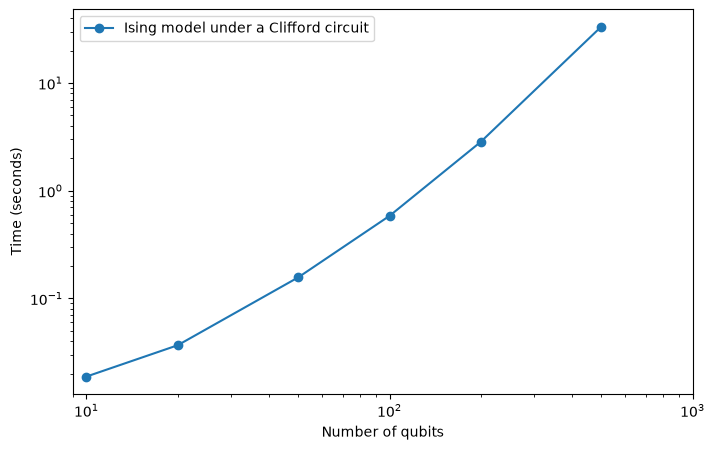

In [22]:
plt.figure(figsize=(8, 5))
plt.plot([10, 20, 50, 100, 200, 500], elapsed_list, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlim(9., 1000)
plt.xlabel("Number of qubits")
plt.ylabel("Time (seconds)")
plt.legend(["Ising model under a Clifford circuit"])
plt.show()